### Mitigrating Cascading Failures in Cloud Infrastructures

The main objective is to create a system that can detect failure from a pre-failure state. The dataset is from a github repository maintained by NetManAIOps. There are 3 files, the train, test, and test_label. The training data is what normal operating data looks like. The test data contains real world data which includes actual system failures. The test_label is a binary file that indicate which test case is a failure. 

### Step 0: Import dataset and install essential libraries to the environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler


### Step 1: Data Ingestion and Preperation

In [2]:
train_path  = 'machine-1-1_train.txt'
test_path = 'machine-1-1_test.txt' 
label_path = 'machine-1-1_label.txt'

# Load datasets
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)
label_df = pd.read_csv(label_path, header=None)

num_features = train_df.shape[1]
feature_cols = [f"metric_{i}" for i in range(num_features)]

train_df.columns = feature_cols
test_df.columns = feature_cols



# Display basic information about the datasets
# print("Training Data Shape:", train_df.shape)   

test_df["is_anomaly"] = label_df.iloc[:, 0]

### Step 2: Exploratory Analysis

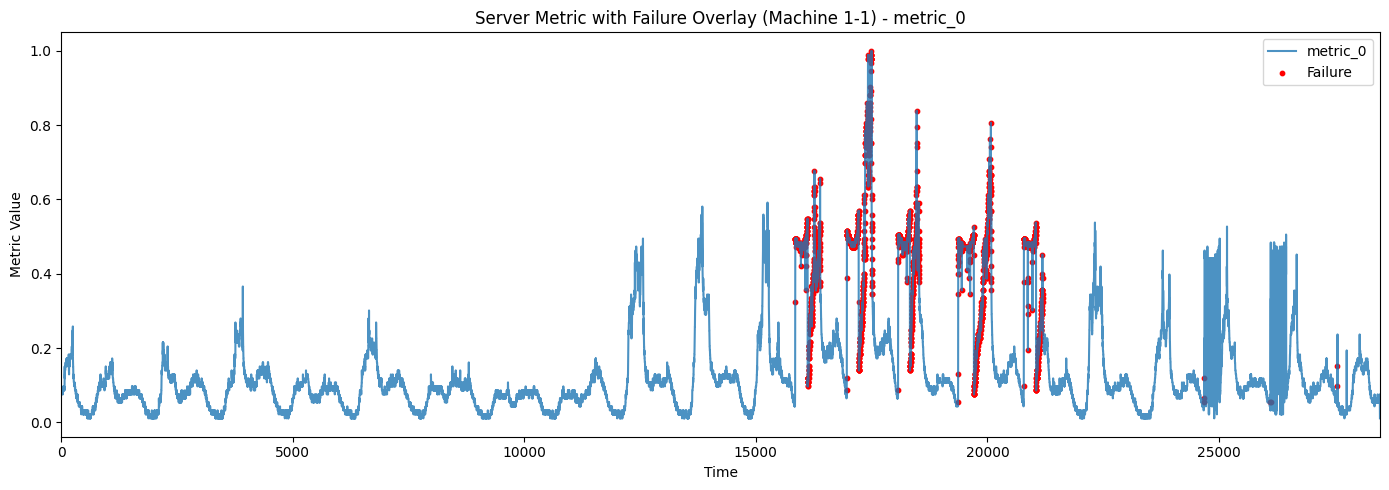

In [3]:
# # Display the graph
# for i in range(num_features):
#     plt.figure(figsize=(14, 5))

#     plt.plot(test_df.index, test_df[f"metric_{i}"], label=f"metric_{i}", alpha=0.8)

#     # Highlight anomaly regions
#     anomalies = test_df[test_df["is_anomaly"] == 1]
#     plt.scatter(
#         anomalies.index,
#         anomalies[f"metric_{i}"],
#         color="red",
#         label="Failure",
#         s=10
#     )

plt.figure(figsize=(14, 5))

plt.plot(test_df.index, test_df[f"metric_0"], label=f"metric_0", alpha=0.8)
# Highlight anomaly regions
anomalies = test_df[test_df["is_anomaly"] == 1]
plt.scatter(
    anomalies.index,
    anomalies[f"metric_0"],
    color="red",
    label="Failure",
    s=10
)

plt.title(f"Server Metric with Failure Overlay (Machine 1-1) - metric_0")
plt.xlim(0, train_df.shape[0]) # Set x-axis limits to the range of our data
plt.xlabel("Time")
plt.ylabel("Metric Value")
plt.legend()
plt.tight_layout()

## Heatmap to determine relationship between variables

In [4]:
corr_matrix = test_df.corr().sort_values(by="is_anomaly", ascending = False)

corr_matrix

,metric_0,metric_1,metric_2,metric_3,metric_4,metric_5,metric_6,metric_7,metric_8,metric_9,...,metric_29,metric_30,metric_31,metric_32,metric_33,metric_34,metric_35,metric_36,metric_37,is_anomaly
is_anomaly,0.697353,0.307645,0.317597,0.303852,NaN,0.117435,0.252566,NaN,0.133707,0.166396,...,0.238142,0.290603,0.323154,0.092096,0.096637,0.290314,0.290314,NaN,NaN,1.000000
metric_0,1.000000,0.648776,0.675447,0.666802,NaN,0.346218,0.338593,NaN,0.191621,0.134045,...,0.396024,0.650947,0.648234,0.184690,0.189960,0.653563,0.653564,NaN,NaN,0.697353
metric_31,0.648234,0.902747,0.938282,0.922493,NaN,0.545738,0.318772,NaN,0.267644,-0.026471,...,0.536986,0.979003,1.000000,0.294199,0.301140,0.951986,0.951987,NaN,NaN,0.323154
metric_2,0.675447,0.965396,1.000000,0.987895,NaN,0.563118,0.332746,NaN,0.263155,-0.019816,...,0.458711,0.972584,0.938282,0.254774,0.259364,0.967388,0.967389,NaN,NaN,0.317597
metric_24,0.652012,0.916888,0.955799,0.944853,NaN,0.549531,0.325335,NaN,0.268955,-0.027629,...,0.586317,0.987857,0.981941,0.398619,0.404741,0.967161,0.967162,NaN,NaN,0.309920
metric_1,0.648776,1.000000,0.965396,0.934546,NaN,0.541198,0.311319,NaN,0.254613,-0.016469,...,0.444626,0.931543,0.902747,0.246074,0.251175,0.927331,0.927332,NaN,NaN,0.307645
metric_3,0.666802,0.934546,0.987895,1.000000,NaN,0.557262,0.341865,NaN,0.255313,-0.022188,...,0.449145,0.964674,0.922493,0.248787,0.252667,0.957858,0.957859,NaN,NaN,0.303852
metric_30,0.650947,0.931543,0.972584,0.964674,NaN,0.582910,0.306370,NaN,0.279894,-0.031983,...,0.501228,1.000000,0.979003,0.283402,0.288662,0.990080,0.990081,NaN,NaN,0.290603
metric_35,0.653564,0.927332,0.967389,0.957859,NaN,0.592805,0.286445,NaN,0.273804,-0.030839,...,0.459561,0.990081,0.951987,0.247693,0.252520,1.000000,1.000000,NaN,NaN,0.290314
metric_34,0.653563,0.927331,0.967388,0.957858,NaN,0.592806,0.286448,NaN,0.273803,-0.030843,...,0.459559,0.990080,0.951986,0.247690,0.252517,1.000000,1.000000,NaN,NaN,0.290314


### Step 3: Feature Engineering 

In [71]:
def create_time_features(df, metrics, window=10, lag=300):
    df_feat = pd.DataFrame()

    for col in metrics:
        df_feat[f"{col}_roll_mean"] = df[col].rolling(window).mean()
        df_feat[f"{col}_roll_std"] = df[col].rolling(window).std()
    
    df_feat["is_anomaly"] = df["is_anomaly"]

    return df_feat

In [72]:
selected_metrics = ["metric_0", "metric_31", "metric_2", "metric_24", "metric_1", "metric_3"]

test_feat = create_time_features(test_df, selected_metrics)




In [73]:
test_feat = test_feat.dropna().reset_index(drop=True)

In [74]:
X_test = test_feat.drop(columns=["is_anomaly"])
y_test = test_feat["is_anomaly"]


### Step 4: Model Training

In [75]:
xtrain, xtest, ytrain, ytest = train_test_split(X_test, y_test, test_size=.3, shuffle=False)

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(xtrain)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=xtrain.columns)


In [76]:
from sklearn.ensemble import RandomForestClassifier


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",   
    random_state=42,
    n_jobs=-1
)

rf.fit(xtrain, ytrain)


,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Parameter Tuning

In [77]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": randint(50,200),
    "max_depth": randint(10,50),
    "min_samples_split": randint(2,20),
    "min_samples_leaf" : randint(1,10)
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    cv=5,
    scoring="precision" 
)

random_search.fit(xtrain, ytrain)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'max_depth': <scipy.stats....002D536E5A620>, 'min_samples_leaf': <scipy.stats....002D536E5B2E0>, 'min_samples_split': <scipy.stats....002D536E5AEF0>, 'n_estimators': <scipy.stats....002D53235AD70>}"
,n_iter,10
,scoring,'precision'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


### Step 5: Evaluation

In [78]:
y_pred = random_search.predict(xtest)

y_pred_proba = random_search.predict_proba(xtest)




In [80]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

recall = recall_score(ytest, y_pred)
precision = precision_score(ytest, y_pred)

print(f"Recall:    {recall:.3f}")
print(f"Precision: {precision:.3f}")

Recall:    0.700
Precision: 0.251


In [81]:
from sklearn.metrics import classification_report
print(classification_report(ytest, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.976     0.852     0.910      7975
           1      0.251     0.700     0.370       566

    accuracy                          0.842      8541
   macro avg      0.614     0.776     0.640      8541
weighted avg      0.928     0.842     0.874      8541



In [86]:
# Convert to numpy for speed
y_true_array = ytest.values

# First occurrence of failure
true_failure_idx = np.where(y_true_array == 1)
predict_failure_idx = np.where(y_pred == 1)

# for i in range(len(true_failure_idx[0])):
#     print(f"true failures index: {true_failure_idx[0][i]} Predicted Index: {predict_failure_idx[0][i]}")


In [83]:
y_pred_array = y_pred

pred_failure_indices = np.where(y_pred_array == 1)[0]

if len(pred_failure_indices) == 0:
    print("⚠️ Model never raised an alarm.")
    lead_time = None
else:
    pred_failure_idx = pred_failure_indices[0]


In [84]:
lead_time_steps = true_failure_idx - pred_failure_idx

In [85]:
lead_time_seconds = lead_time_steps
lead_time_minutes = lead_time_seconds / 60

for i in range(len(lead_time_seconds[0])): 
    print(f"Lead Time: {lead_time_seconds[0][i]} seconds ({lead_time_minutes[0][i]:.2f} minutes)")


Lead Time: 0 seconds (0.00 minutes)
Lead Time: 1 seconds (0.02 minutes)
Lead Time: 2 seconds (0.03 minutes)
Lead Time: 3 seconds (0.05 minutes)
Lead Time: 4 seconds (0.07 minutes)
Lead Time: 5 seconds (0.08 minutes)
Lead Time: 6 seconds (0.10 minutes)
Lead Time: 7 seconds (0.12 minutes)
Lead Time: 8 seconds (0.13 minutes)
Lead Time: 9 seconds (0.15 minutes)
Lead Time: 10 seconds (0.17 minutes)
Lead Time: 11 seconds (0.18 minutes)
Lead Time: 12 seconds (0.20 minutes)
Lead Time: 13 seconds (0.22 minutes)
Lead Time: 14 seconds (0.23 minutes)
Lead Time: 15 seconds (0.25 minutes)
Lead Time: 16 seconds (0.27 minutes)
Lead Time: 17 seconds (0.28 minutes)
Lead Time: 18 seconds (0.30 minutes)
Lead Time: 19 seconds (0.32 minutes)
Lead Time: 20 seconds (0.33 minutes)
Lead Time: 21 seconds (0.35 minutes)
Lead Time: 22 seconds (0.37 minutes)
Lead Time: 23 seconds (0.38 minutes)
Lead Time: 24 seconds (0.40 minutes)
Lead Time: 25 seconds (0.42 minutes)
Lead Time: 26 seconds (0.43 minutes)
Lead Time: 

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

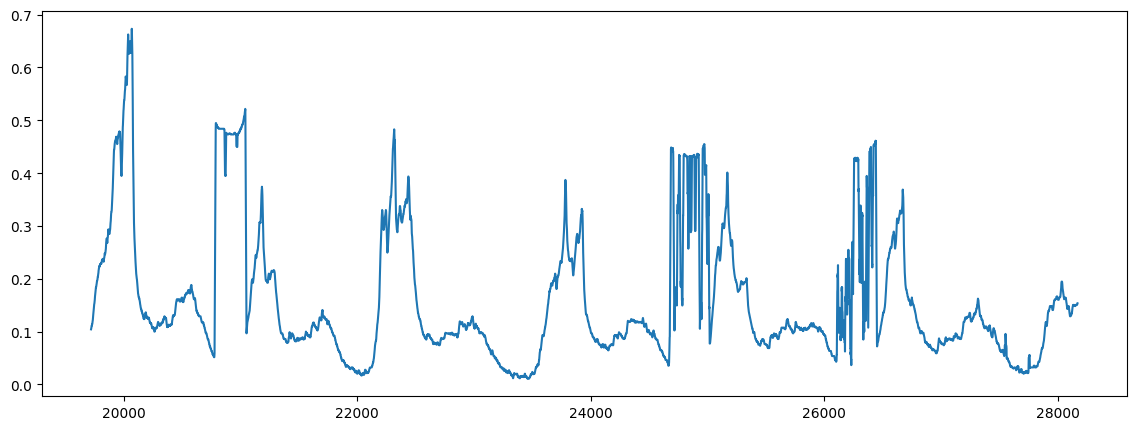

In [70]:
plt.figure(figsize=(14, 5))

plt.plot(xtest.index, xtest["metric_0_roll_mean"], label="Metric 0")

# Actual failure
plt.axvline(
    xtest.index[true_failure_idx],
    color="red",
    linestyle="--",
    label="Actual Failure"
)

# Predicted failure
if len(pred_failure_indices) > 0:
    plt.axvline(
        xtest.index[pred_failure_idx],
        color="orange",
        linestyle="--",
        label="Predicted Failure"
    )

plt.legend()
plt.title("Early Failure Detection (Lead-Time Visualization)")
plt.tight_layout()
plt.show()
